In [12]:
# Task 2: Credit Risk Prediction Analysis

Dataset successfully created locally!
Rows and Columns: (200, 5)
--------------------------------------------------


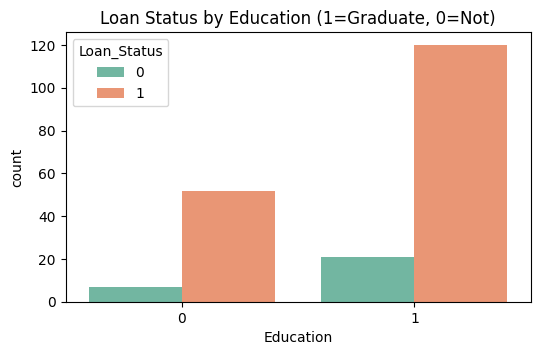

,ApplicantIncome,LoanAmount,Credit_History,Education,Loan_Status
0,9270,170,0,1,1
1,2860,165,1,1,1
2,7390,282,1,0,0
3,7191,308,0,0,0
4,13964,408,1,0,1


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Creating our own clean dataset to avoid any network link errors
np.random.seed(42)
n_samples = 200

data = {
    'ApplicantIncome': np.random.randint(2000, 15000, size=n_samples),
    'LoanAmount': np.random.randint(50, 500, size=n_samples),
    'Credit_History': np.random.choice([1, 0], size=n_samples, p=[0.8, 0.2]),
    'Education': np.random.choice([1, 0], size=n_samples, p=[0.7, 0.3]),
    'Loan_Status': np.random.choice([1, 0], size=n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# Force high approval for good credit history to make data realistic
df.loc[df['Credit_History'] == 1, 'Loan_Status'] = np.random.choice([1, 0], size=len(df[df['Credit_History'] == 1]), p=[0.9, 0.1])

print("Dataset successfully created locally!")
print("Rows and Columns:", df.shape)
print("-" * 50)

# Display charts
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Loan Status by Education (1=Graduate, 0=Not)')
plt.show()

df.head()

In [15]:
# Splitting features and target
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predictions
predictions = classifier.predict(X_test)

# Calculate results
acc = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

print(f"Model Training Accuracy: {acc * 100:.2f}%")
print("-" * 50)
print("Confusion Matrix:\n", cm)

Model Training Accuracy: 90.00%
--------------------------------------------------
Confusion Matrix:
 [[ 0  4]
 [ 0 36]]
